translate.py - 구글 번역기에 한국어 넣고 영어로 번역 후 번역결과 가져오는 함수 만들기

In [4]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )
url = "https://search.shopping.naver.com/book/home"
driver.get(url)
wait = WebDriverWait(driver, 10)
search_text_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "._searchInput_search_text_83jy9._searchInput_placeholder_AG5yA._nlog_click")))
search_text_box.send_keys("파이썬")
search_text_box.send_keys(Keys.ENTER)

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )
url = "https://search.shopping.naver.com/book/home"
driver.get(url)
wait = WebDriverWait(driver, 10)
search_text_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "._searchInput_search_text_83jy9._searchInput_placeholder_AG5yA._nlog_click")))
search_text_box.send_keys("파이썬")
search_text_box.send_keys(Keys.ENTER)

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
import pandas as pd
from book_dbio import to_book_db
from book_dbio_tr import to_book_db


keyword = input("검색할 책을 입력해 주세요. ")
eng_keyword = kor2eng(keyword)

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")
# options.add_argument("--headless")  
# options.add_argument("--no-sandbox")
# options.add_argument("--disable-dev-shm-usage")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )


url = "https://search.shopping.naver.com/book/home"
driver.get(url)
wait = WebDriverWait(driver, 10)
search_text_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "._searchInput_search_text_83jy9._searchInput_placeholder_AG5yA._nlog_click")))
search_text_box.send_keys(keyword)
search_text_box.send_keys(Keys.ENTER)

for num in range(1, 6):
    print(f"{num} / {len(range(1,6))} 페이지 작업중", end="\n")
    # 페이지 시작부터 끝까지 스크롤하기
    for scroll in range(0, 8001, 1000):
        driver.execute_script(f"window.scrollTo({0}, {scroll})")
        time.sleep(0.5)

    # 책 목록 전체 가져오기 find_elements
    book_list = driver.find_elements(By.CSS_SELECTOR, ".bookListItem_item_book__RbpgP")

    # 반복문을 이용해 전체 40개 책 자료 추출하기
    for idx, book in enumerate(book_list):
        # 책 제목  bookListItem_title__1mWGq
        title = book.find_element(By.CSS_SELECTOR, ".bookListItem_title__1mWGq").text
        #세부링크 bookListItem_item_inner__edK7P
        detail_link = book.find_element(By.CSS_SELECTOR, ".bookListItem_item_inner__edK7P > a").get_attribute("href")
        try:
            # 저자 .bookListItem_define_item__jqcW8.bookListItem_define_data__fu2A5
            author = book.find_element(By.CSS_SELECTOR, ".bookListItem_define_item__jqcW8 > .bookListItem_define_data__fu2A5").text
        except Exception:
            author = "Unknown"
        try:
            # 출판사 .bookListItem_define_item__jqcW8 bookListItem_publish__6XykH.bookListItem_define_data__fu2A5
            publisher = book.find_element(By.CSS_SELECTOR, ".bookListItem_publish__6XykH .bookListItem_define_data__fu2A5").text
        except Exception:
            publisher = "Unknown"
        try:
            # 출간일 .bookListItem_detail_date__6_wYJ
            pub_date = book.find_element(By.CSS_SELECTOR, ".bookListItem_detail_date__6_wYJ").text
        except Exception:
            pub_date = "Unknown"
        try:
            # 평점 .bookListItem_grade__e60mi
            grade = float(book.find_element(By.CSS_SELECTOR, ".bookListItem_grade__e60mi").text[2:5])
        except Exception:
            grade = 0.0
        try:    
            # 가격 .bookPrice_price__Nv4Ee > em
            price = int(book.find_element(By.CSS_SELECTOR, ".bookPrice_price__Nv4Ee > em").text.replace(",", ""))
        except Exception:
            price = 0

        temp = (title, detail_link, author, publisher, pub_date, grade, price)
        columns = ("title", "detail_link", "author", "publisher", "pub_date", "grade", "price")
        result = pd.DataFrame([temp], columns=columns)
        # 데이터프레임을 CSV로 저장하되 내용 추가하면서 저장하기
        to_book_db(keyword, result)
#         result.to_csv("./scraping_results/네이버책_selenium.csv", mode="a", header=False, index=False, encoding="utf-8-sig")
        print(f"                                                       {idx+1}/{len(book_list)} DB 저장완료", end="\r")
    # 페이지 넘김 버튼 찾기 .Paginator_list_paging__XbuO8
    paginator = driver.find_element(By.CSS_SELECTOR, ".Paginator_list_paging__XbuO8")
    paginator.find_element(By.LINK_TEXT, f"{num+1}").click()

In [24]:
from sqlalchemy import create_engine
import pymysql
pymysql.install_as_MySQLdb()
import pandas as pd



keyword = input("검색할 책을 입력해 주세요. ")
# eng_keyword = kor2eng(keyword)

# options = Options()
# options.add_experimental_option("detach", True)
# options.add_argument("start-maximized")
# options.add_argument("Chrome/135.0.0.0")
# options.add_argument("lang=ko_KR")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )

url = "https://translate.google.com/?source=gtx&sl=ko&tl=en&op=translate"
driver.get(url)
wait = WebDriverWait(driver, 10)
search_text_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "div > textarea")))
search_text_box.send_keys(keyword)
search_text_box.send_keys(Keys.ENTER)


#yDmH0d > c-wiz > div > div.ToWKne > c-wiz > div.OlSOob > c-wiz > div.ccvoYb > div.AxqVh > div.OPPzxe > div > c-wiz > span > span > div > textarea

검색할 책을 입력해 주세요. 핀테크 박스 만들기


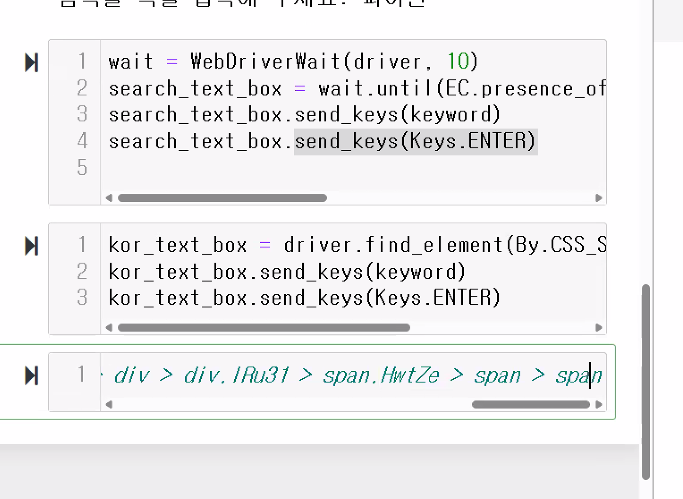

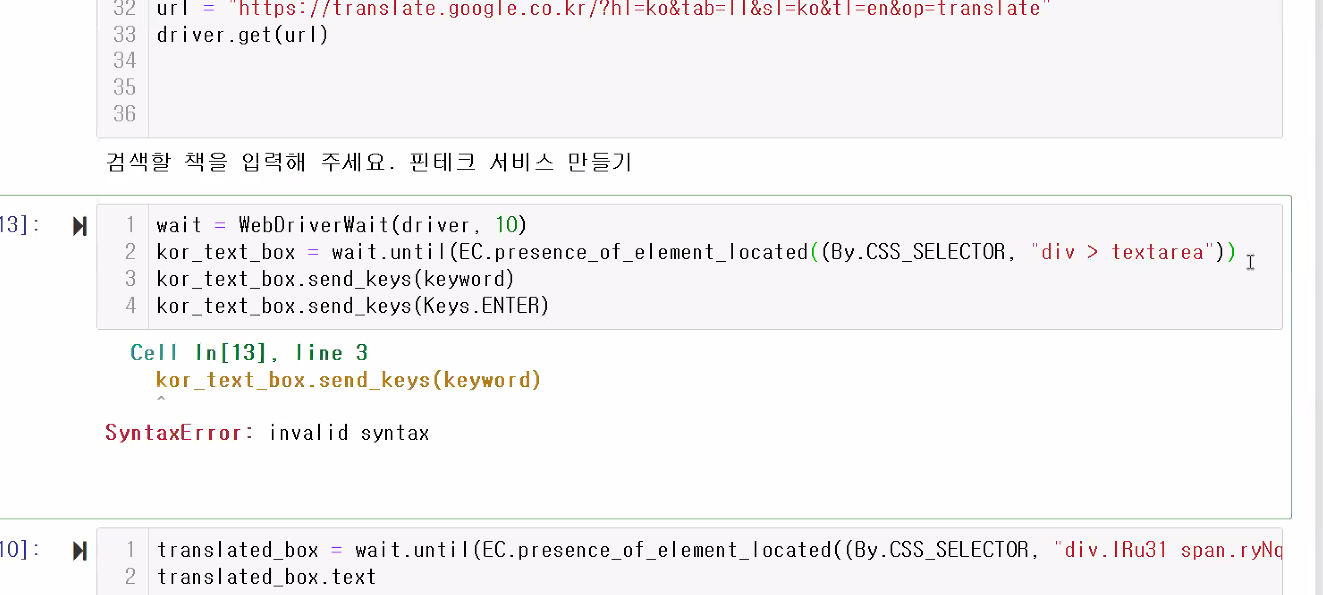

In [21]:
wait = WebDriverWait(driver, 10)
search_text_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "div > textarea")))
search_text_box.send_keys(keyword)
search_text_box.send_keys(Keys.ENTER)

In [22]:
kor_text_box = driver.find_element(By.CSS_SELECTOR, "div > textarea")
kor_text_box.send_keys(keyword)
kor_text_box.send_keys(Keys.ENTER)

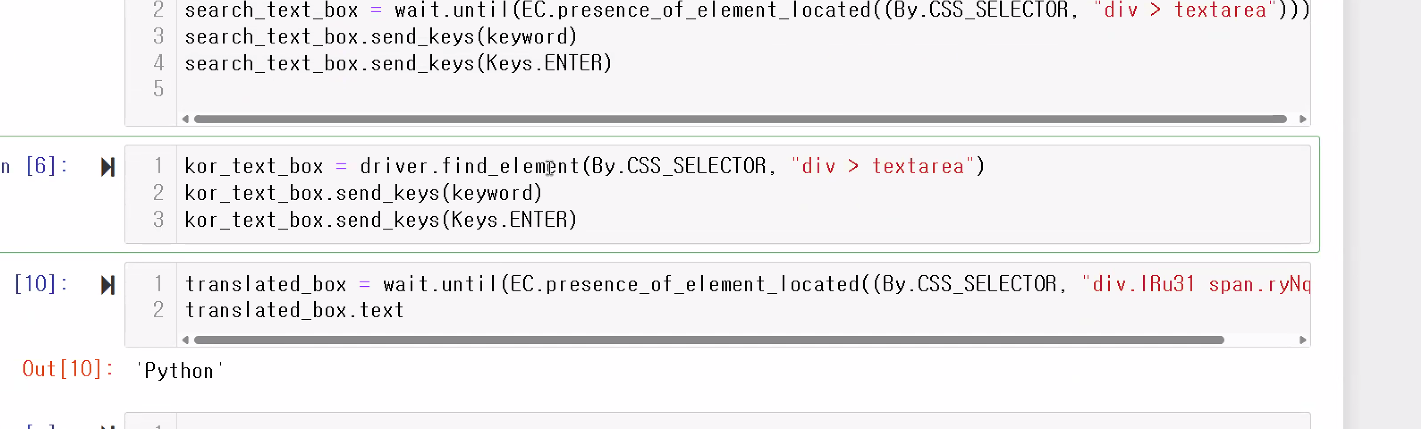

In [23]:
translated_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "div.IRu31 span.ryNqvb")).text
driver.find_element(By.CSS_SELECTOR, "div.IRu31 span.ryNqvb").text
search_text_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "div > textarea")))

SyntaxError: invalid syntax (1205613939.py, line 2)